In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import cv2

import numpy as np 

import torch
import torch.nn as nn
import torch.nn.functional as F

from box import Box
import yaml

import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation as R

import random 

import time 

root_dir = os.path.abspath('../..')
if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.dataset import SonarSimDataset, visu_format

# from src.models.update import Update, neighbours
# from src.models.graph_inference import Graph as Graph_interference
# from src.models.graph_training import Graph as Graph_train
# from src.models.bundle_adjustment import BundleAdjustment
# from src.models.dpso import DPSO 

In [3]:


test = SonarSimDataset('C:/Users/janis/Projekty/Magisterka/SonarOdometry/data', 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/config/training.yaml')
test.print_info()
dtlen = print(len(test))

Dataset content:
Number of sequences: 2
Total frames number: 550
Seq: seq_1: 500 frames.
Seq: seq_3: 50 frames.
542


In [4]:
samplenum = random.randint(0, 5)
single_series, time, trajectory = test[samplenum]
print('shape of single output: ', single_series.shape)
print('time shape:', time.shape)
print('traj shape:', trajectory.shape)

shape of single output:  torch.Size([5, 1, 800, 768])
time shape: (5, 1)
traj shape: (5, 7)


a
a
a
a
a


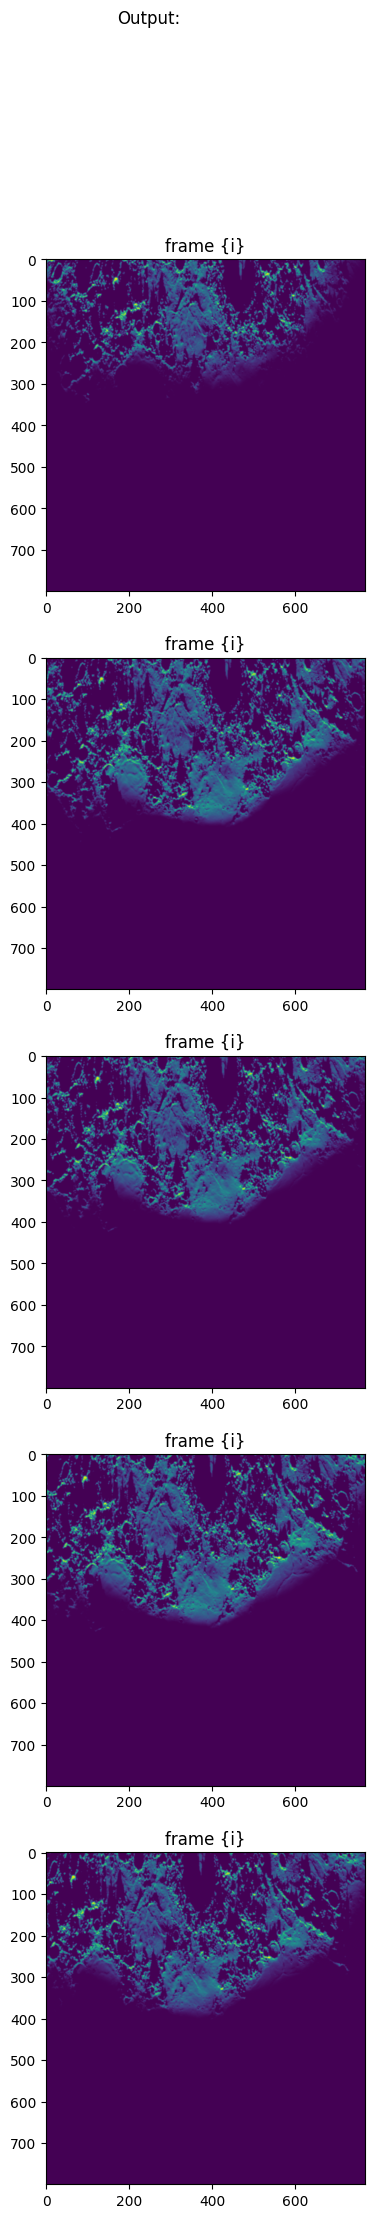

In [ ]:
frames = visu_format(single_series)

n = len(frames)

fig, ax = plt.subplots(n, 1, figsize = (45,25))
fig.suptitle(f'Output:')
for i in range(n):
    ax[i].set_title(f'frame {i}')
    ax[i].imshow(frames[i])


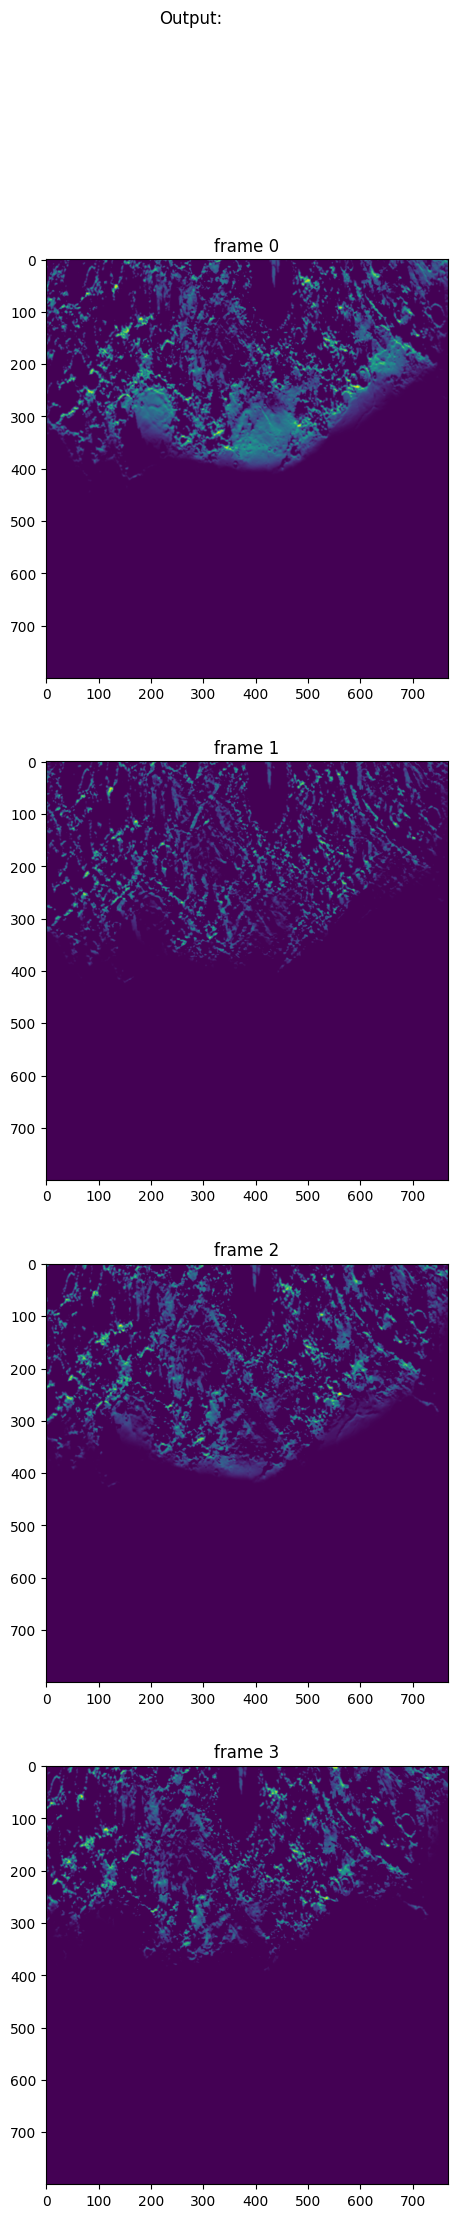

In [13]:
n = len(frames)

fig, ax = plt.subplots(n-1, 1, figsize = (45,25))
fig.suptitle(f'Output:')
for i in range(n-1):
    ax[i].set_title(f'frame {i}')
    ax[i].imshow(np.clip(frames[i+1] - frames[i], 0, 255))